# Script to calc all params for Radar Module
>**USE:** 
>Execute class & function definitions and then change params in second Cell
## Class definition

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

class Radar:
    def __init__(self, sampling_rate, fft_size, T_sweep):
        # Hardcoded sensor parameters from the datasheet
        self.Vcc_3_3V = 3.3  # Supply voltage (V)
        self.Icc = 75e-3  # Supply current (A)
        self.VCO_input = 3.3  # VCO input voltage (V)
        self.R_vco = 20e3  # VCO input resistance (Ω)
        self.f_tx = 24.150e9  # Transmitter frequency (GHz)
        self.bandwith = 260e6  # Frequency bandwith (MHz)
        self.S_vco = 80e6  # VCO sensitivity (MHz/V)
        self.B_vco = 3e6  # VCO Modulation Bandwidth (MHz)
        self.P_tx = 12  # Output power (EIRP) (dBm)
        self.T_on = 6e-6  # Turn-on Time (s)
        self.P_spur = -30  # Spurious emission (dBm)
        self.G_ant = 8.6  # Antenna gain (dBi)
        self.G_rx = 18  # Receiver gain (dB)
        self.P_rx_min = -105  # Receiver sensitivity (dBm)
        self.D_system = -118  # Overall sensitivity (dBc)
        self.R_if = 100  # IF output impedance (Ω)
        self.delta_U_if = -2  # I/Q amplitude balance (dB)
        self.Phi_if = 90  # I/Q phase shift (°)
        self.B_if = 10e6  # IF frequency range (3 dB Bandwidth) (Hz)
        self.U_noise = 45e-9  # IF noise voltage (nV/√Hz)
        self.U_os = -1.47  # IF output offset voltage (dBV/Hz)
        self.D_supply = -50  # Supply rejection (dB)
        self.W_E = 80  # Horizontal -3dB beamwidth (E-Plane) (°)
        self.W_H = 34  # Vertical -3dB beamwidth (H-Plane) (°)
        self.D_h = -12  # Horizontal sidelobe suppression (dB)
        self.D_v = -20  # Vertical sidelobe suppression (dB)
        #physical constants
        self.c = 299792458 # Speed of light in m/s
    
        # Additional initialization parameters
        self.B_sweep = self.bandwith
        self.sampling_rate = sampling_rate  # Hz
        self.fft_size = fft_size  # FFT points
        self.c = 299792458  # Speed of light in m/s
        self.T_sweep = T_sweep
        
        # Check if T_sweep is fft_size/sampling_rate to avoid errors
        if not np.isclose(self.T_sweep, self.fft_size / self.sampling_rate):
            print("!! delta_f_beat is not equal to FFT resolution! (T_s * N_fft = T_sweep)")
        self.slope = self.B_sweep / self.T_sweep
        self.delta_f_beat = sampling_rate / fft_size

        self.max_range_fft = self.max_range_fft()
    
    def range_resolution(self):
        """Calculate range resolution."""
        return self.c / (2 * self.bandwith)

    def max_range_fft(self):
        """Calculate max range using FMCW radar formula."""
        return (self.sampling_rate * self.c * self.T_sweep) / (4 * self.B_sweep)
    
    def radar_equation_range(self, target_rcs, L=0):
        """Compute the radar range using the reduced radar wavefunction from datasheet
        use target rcs1m^2 for moving person and >50m^2 for a movingcar
        L is other losses in dB (environmental, etc)"""
        s = self.D_system + L
        return 0.0167 * 10**(-s/40) * np.power(target_rcs, 1/4)

    def max_beat_freq(self, target_rcs):
        """Calculate the maximum beat frequency for a given target RCS"""
        s = self.B_sweep / self.T_sweep
        max_phys_range = self.radar_equation_range(target_rcs)

        return 2 * s * max_phys_range / self.c   

    def radar_equation_range_full(self, target_rcs=1, L=10):
        """Compute the maximum range using the full radar equation. 
        very different results than the one given in the AN"""
        # Convert dB values to linear scale
        P_tx = 10**((self.P_tx - 30) / 10)  # Convert dBm to Watts
        G_tx = 10**(self.G_ant / 10)  # Convert dBi to linear gain
        G_rx = 10**(self.G_rx / 10)  # Convert dBi to linear gain
        S_min = 10**((self.P_rx_min - 30) / 10)  # Convert dBm to Watts
        
        # Calculate wavelength
        wavelength = self.c / self.f_tx
        
        # Compute radar range using the full radar equation
        R_full = ((P_tx * G_tx * G_rx * wavelength**2 * target_rcs) / 
                  ((4 * np.pi)**3 * L * S_min))**(1/4)
        
        return R_full

    def estimate_tau_vco(self, V_step=0.01):
        """Estimate the VCO response time constant (tau) based on system parameters and T_sweep."""
        tau_initial = (V_step * self.S_vco) / self.B_vco  # Initial tau based on VCO response
        return tau_initial * (self.T_sweep / (self.T_sweep + tau_initial))  # Adjusted for sweep time
    

    def plot_sweep_curve(self, dac_bits, dac_sampling_rate, dac_bandwidth):
        # Extract parameters from the class
        V_max = self.VCO_input  # Max input voltage (V)
        K_v = self.S_vco  # VCO Sensitivity (Hz/V)
        B_sweep = self.B_sweep  # Bandwidth (Hz)
        f_base = self.f_tx  # Base frequency (Hz)
        f_m = self.B_vco  # VCO modulation bandwidth (Hz)
        T_sweep = self.T_sweep  # Sweep time (s)

        # Time Vector (DAC operates at a fixed sampling rate)
        num_samples = int(dac_sampling_rate * T_sweep)  # DAC output sample count
        t = np.linspace(0, T_sweep, num_samples)  # Time axis

        # Generate an Ideal DAC Input Ramp
        V_in_ideal = (V_max / T_sweep) * t  # Perfect ramp

        # Apply DAC Quantization (Simulating bit-depth effects)
        dac_levels = 2**dac_bits  # Number of discrete DAC levels
        V_in_quantized = np.round(V_in_ideal * (dac_levels - 1) / V_max) * (V_max / (dac_levels - 1))

        # Simulate DAC as a Low-Pass Filter
        Wn_dac = dac_bandwidth / (dac_sampling_rate / 2)  # Normalize cutoff frequency for DAC filter
        if Wn_dac >= 1:
            raise ValueError(f"DAC cutoff frequency Wn={Wn_dac} is too high. Increase DAC sampling rate.")

        b_dac, a_dac = butter(1, Wn_dac, btype='low')  # 1st-order low-pass filter for DAC
        V_in_filtered = filtfilt(b_dac, a_dac, V_in_quantized)  # Apply low-pass filtering

        # Convert DAC Output to Frequency (VCO Modulation)
        f_ideal = f_base + K_v * V_in_filtered - B_sweep / 2  # Apply VCO range shift

        # Simulate VCO Response as a Low-Pass Filter
        dt = t[1] - t[0]  # Time step
        fs = 1 / dt  # Effective sampling frequency

        Wn_vco = f_m / (fs / 2)  # Normalize cutoff frequency for VCO filter
        if Wn_vco >= 1:
            raise ValueError(f"VCO cutoff frequency Wn={Wn_vco} is too high. Decrease f_m or increase T_sweep.")

        b_vco, a_vco = butter(1, Wn_vco, btype='low')  # 1st-order low-pass filter for VCO
        f_actual = filtfilt(b_vco, a_vco, f_ideal)  # Apply low-pass filtering

        # Create figure
        plt.figure(figsize=(10, 8))  # Adjust size for better readability
        
        # First subplot - DAC Output Frequency
        plt.subplot(2, 1, 1)  # 2 rows, 1 column, first subplot
        plt.plot(t * 1e6, f_ideal / 1e9, label="DAC Output Frequency", linestyle="dashed", color='b')
        plt.xlabel("Time (µs)")
        plt.ylabel("Frequency (GHz)")
        plt.title(f"DAC Output Frequency (T_sweep = {T_sweep * 1e6:.2f} µs)")
        plt.legend()
        plt.grid()
        
        # Second subplot - VCO Response
        plt.subplot(2, 1, 2)  # 2 rows, 1 column, second subplot
        plt.plot(t * 1e6, f_actual / 1e9, label="VCO Response", linewidth=2, color='r')
        plt.xlabel("Time (µs)")
        plt.ylabel("Frequency (GHz)")
        plt.title("VCO Response with DAC Imperfections")
        plt.legend()
        plt.grid()
        
        # Show both plots
        plt.tight_layout()  # Adjust layout to prevent overlap
        plt.show()



In [2]:

#params fft
sampling_rate = 102.4e3  # 1 MS/s
fft_size = 1024
#target for physical range limit calc
target_rcs = 1  # 1 m^2
#params FMCW
T_sweep = 10e-3  # 1 ms

radar = Radar(sampling_rate, fft_size, T_sweep)
print("Range Resolution: {:.2f} meters".format(radar.range_resolution()))
print("Max Range (FFT): {:.2f} meters".format(radar.max_range_fft))
print("Radar Equation Range: {:.2f} meters".format(radar.radar_equation_range(target_rcs,L=0)))


Range Resolution: 0.58 meters
Max Range (FFT): 295.18 meters
Radar Equation Range: 14.88 meters


In [4]:
import numpy as np

#prints all results not just minimum
print_all = False

# Physical distance params
L = 0  # Other system losses
target_rcs = 50  # RCS for a moving car (m^2)

# Choose T_sweep range which is tested
T_sweep_range = np.linspace(1e-3, 5e-3, num=5)  

# Available FFT sizes in CMSIS DSP
fft_sizes = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
#choose the minimum fft size considered:
fft_sizes_min_index = 3
fft_sizes_max_index = 7

fft_sizes = fft_sizes[fft_sizes_min_index:fft_sizes_max_index]

# Calculate sampling frequency for each FFT size used in CMSIS DSP
def get_sampling_freqs(fft_sizes, T_sweep):
    sampling_freqs = [size / T_sweep for size in fft_sizes] 
    return sampling_freqs

# Loop through T_sweep values
r = Radar(102.4e3, 1024,  1024/102.4e3) 
print("max physical range: {:.2f}m".format(r.radar_equation_range(target_rcs)))
print("() after max f_beat indicate factor below nyquist frequency")
if not(print_all):
    print("Only the minimum FFT_size shown")

for T_sweep in T_sweep_range:
    sampling_freqs = get_sampling_freqs(fft_sizes, T_sweep)
    found = False
    for i in range(len(fft_sizes)):
        r = Radar(sampling_freqs[i], fft_sizes[i], T_sweep) 

        if (r.max_range_fft > r.radar_equation_range(target_rcs))&(not found or print_all):
            found = True
            if(r.max_beat_freq(target_rcs)*2 <= sampling_freqs[i]):
                fs = sampling_freqs[i]
                fft_size = fft_sizes[i]
                max_b = r.max_beat_freq(target_rcs)
                print("T_sweep={:.1f}ms: FFT={:.2f}m, fs: {:.2f} kHz, FFT size: {}|  max f_beat: {:.2f}kHz ({:.2f}), delta_f_beat: {:.2f}Hz"
                .format(T_sweep * 1e3, r.max_range_fft, 
                fs * 1e-3, fft_size, max_b * 1e-3, fs/(max_b*2), fs/fft_size))



max physical range: 39.58m
() after max f_beat indicate factor below nyquist frequency
Only the minimum FFT_size shown
T_sweep=1.0ms: FFT=73.80m, fs: 256.00 kHz, FFT size: 256|  max f_beat: 68.65kHz (1.86), delta_f_beat: 1000.00Hz
T_sweep=2.0ms: FFT=73.80m, fs: 128.00 kHz, FFT size: 256|  max f_beat: 34.33kHz (1.86), delta_f_beat: 500.00Hz
T_sweep=3.0ms: FFT=73.80m, fs: 85.33 kHz, FFT size: 256|  max f_beat: 22.88kHz (1.86), delta_f_beat: 333.33Hz
T_sweep=4.0ms: FFT=73.80m, fs: 64.00 kHz, FFT size: 256|  max f_beat: 17.16kHz (1.86), delta_f_beat: 250.00Hz
T_sweep=5.0ms: FFT=73.80m, fs: 51.20 kHz, FFT size: 256|  max f_beat: 13.73kHz (1.86), delta_f_beat: 200.00Hz


!! delta_f_beat is not equal to FFT resolution! (T_s * N_fft = T_sweep)


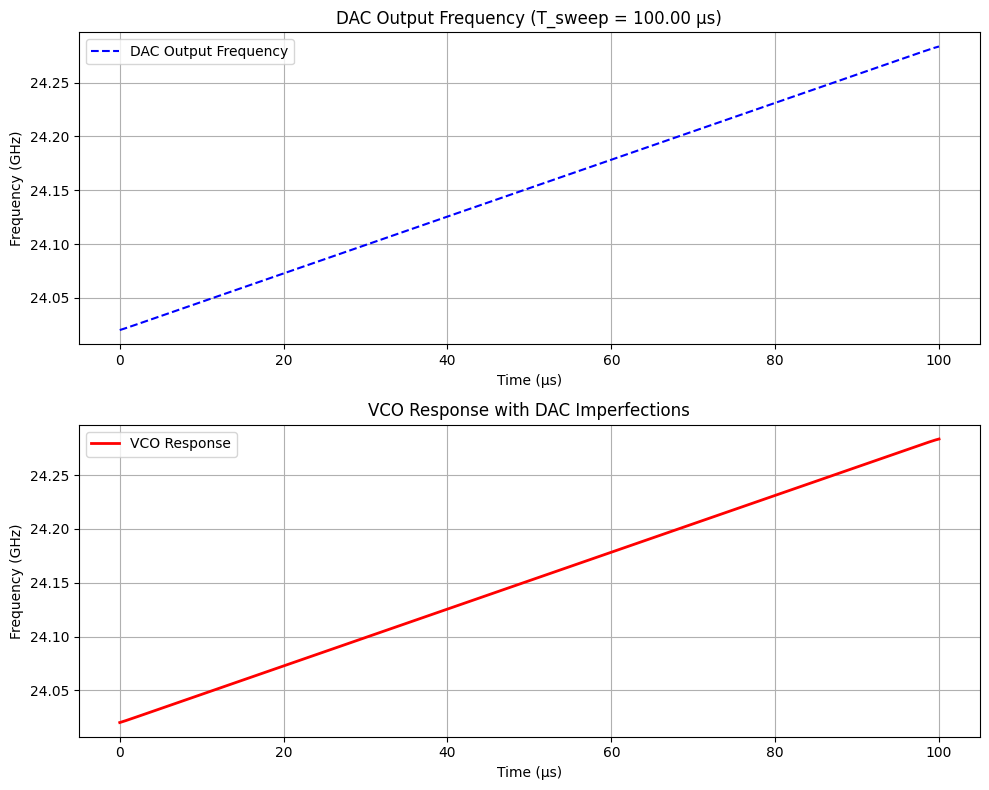

In [38]:

##NOT DONE YET

T_sweep = 1e-4  
#signal step size for VCO
dac_bits = 12
dac_sampling_rate = 10e6
dac_bandwidth = 300e3


#doesnt matter
sampling_rate = 102.4e3  # 102.4 kHz
fft_size = 1024

radar = Radar(sampling_rate, fft_size, T_sweep)

radar.plot_sweep_curve(dac_bits, dac_sampling_rate, dac_bandwidth)

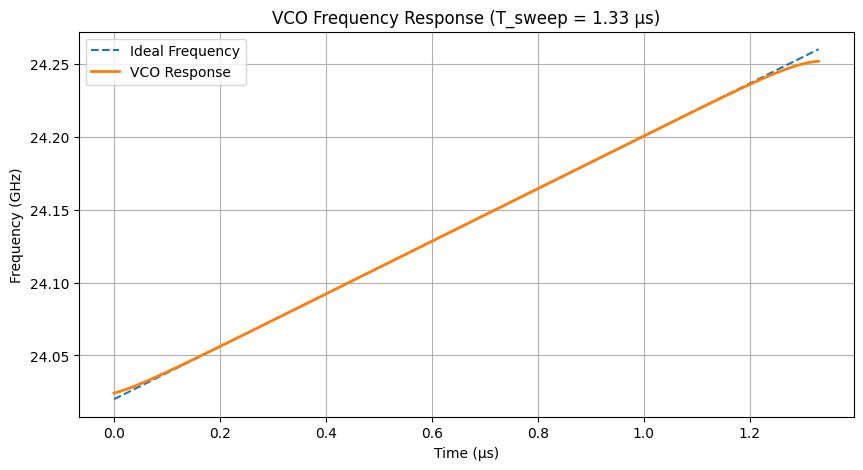

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def simulate_vco_response(T_sweep, f_m=3e6):
    # Given Constants
    V_max = 3.0  # Max input voltage (V)
    K_v = 80e6  # VCO Sensitivity (Hz/V)
    B_sweep = 260e6  # Bandwidth (Hz)
    f_base = 24.150e9  # Base frequency (Hz)

    # Time Vector
    num_samples = 1000  # Number of time samples
    t = np.linspace(0, T_sweep, num_samples)  # Time axis

    # Ideal Chirp Frequency Response
    V_in = (V_max / T_sweep) * t  # Ramp input from 0 to 3V
    f_ideal = f_base + K_v * V_in - B_sweep / 2  # Apply VCO range shift

    # Sampling frequency
    dt = t[1] - t[0]  # Time step
    fs = 1 / dt  # Sampling frequency

    # Digital Butterworth Low-Pass Filter for VCO
    Wn = f_m / (fs / 2)  # Normalize cutoff frequency for digital filter
    if Wn >= 1:
        raise ValueError(f"Filter cutoff frequency Wn={Wn} is too high. Decrease f_m or increase T_sweep.")

    b, a = butter(1, Wn, btype='low')  # 1st-order low-pass filter
    f_actual = filtfilt(b, a, f_ideal)  # Apply zero-phase filtering

    # Plot Results
    plt.figure(figsize=(10, 5))
    plt.plot(t * 1e6, f_ideal / 1e9, label="Ideal Frequency", linestyle="dashed")
    plt.plot(t * 1e6, f_actual / 1e9, label="VCO Response", linewidth=2)
    plt.xlabel("Time (µs)")
    plt.ylabel("Frequency (GHz)")
    plt.title(f"VCO Frequency Response (T_sweep = {T_sweep * 1e6:.2f} µs)")
    plt.legend()
    plt.grid()
    plt.show()

# Example Usage
simulate_vco_response(T_sweep=1.33e-6)  # 43.33 µs for accurate tracking
